# 1D Holstein plotting

This notebook discovers available `Holstein31_alpha*_bd_{singleset,multiset}` results under this directory and plots:

1. Maximum bond entropy vs time.
2. Relative RMSD convergence error using doubled bond dimension as reference.

The loader prefers `.npz` files because they contain `time_series`, `e_occupations`, and `S_maxbond`. If only `.xlsx` exists, it is used for RMSD and skipped for the entropy plot.

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 8.5,
    "axes.grid": True,
    "grid.alpha": 0.28,
})

DEFAULT_DT = 0.1
TIME_SCALE = 2 * np.pi
SAVE_FIGURES = True
RELATIVE_ERROR_ABS = True

def find_base_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "multiset_202606" / "1DHolstein",
        Path("multiset_202606") / "1DHolstein",
    ]
    for path in candidates:
        if (path / "holstein31_common.py").exists():
            return path.resolve()
    raise FileNotFoundError("Cannot find multiset_202606/1DHolstein.")

BASE_DIR = find_base_dir()
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

print(f"BASE_DIR = {BASE_DIR}")
print(f"FIG_DIR  = {FIG_DIR}")

BASE_DIR = /curie-home/zengjj/Renormalizer/multiset_202606/1DHolstein
FIG_DIR  = /curie-home/zengjj/Renormalizer/multiset_202606/1DHolstein/figures


## Data discovery and helpers

In [3]:
RESULT_RE = re.compile(
    r"Holstein31_alpha(?P<alpha>[0-9.]+)_(?P<bd>\d+)bd_(?P<method>single|multi)set\.(?P<suffix>npz|xlsx)$"
)

def discover_results(base_dir=BASE_DIR):
    """Return one preferred file per (alpha, method, bond dimension)."""
    preferred = {}
    for path in sorted(base_dir.rglob("Holstein31_alpha*_*bd_*.npz")) + sorted(base_dir.rglob("Holstein31_alpha*_*bd_*.xlsx")):
        match = RESULT_RE.match(path.name)
        if not match:
            continue

        alpha = float(match.group("alpha"))
        bd = int(match.group("bd"))
        method = f"{match.group('method')}set"
        key = (alpha, method, bd)

        old = preferred.get(key)
        if old is None or path.suffix == ".npz":
            preferred[key] = {
                "alpha": alpha,
                "method": method,
                "bd": bd,
                "path": path,
                "suffix": path.suffix,
            }

    records = sorted(preferred.values(), key=lambda item: (item["alpha"], item["method"], item["bd"]))
    return records

def load_result(record, default_dt=DEFAULT_DT):
    path = Path(record["path"])
    if not path.exists():
        raise FileNotFoundError(path)

    if path.suffix == ".npz":
        data = np.load(path, allow_pickle=True)
        time = np.asarray(data["time_series"], dtype=float)
        occupations = np.asarray(data["e_occupations"], dtype=float)
        s_maxbond = np.asarray(data["S_maxbond"], dtype=float) if "S_maxbond" in data.files else None
        return time, occupations, s_maxbond

    df = pd.read_excel(path, header=None)
    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
    occupations = df.apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)
    time = np.arange(occupations.shape[0], dtype=float) * default_dt
    return time, occupations, None

def compute_rmsd(time, occupations):
    occupations = np.asarray(occupations, dtype=float)
    _, nsite = occupations.shape
    center = (nsite - 1) / 2
    x = np.arange(nsite, dtype=float)

    norm = occupations.sum(axis=1, keepdims=True)
    rho = np.divide(occupations, norm, out=np.zeros_like(occupations), where=norm > 0)
    rmsd = np.sqrt(np.sum((x - center) ** 2 * rho, axis=1))
    return np.asarray(time, dtype=float) / TIME_SCALE, rmsd

def color_for_alpha_bd(alpha, bd, bds_by_alpha):
    palettes = {
        0.5: plt.cm.Blues,
        1.0: plt.cm.Greens,
        2.0: plt.cm.Reds,
    }
    fallback = [plt.cm.Purples, plt.cm.Oranges, plt.cm.Greys]
    alpha_keys = sorted(bds_by_alpha)
    cmap = palettes.get(alpha, fallback[alpha_keys.index(alpha) % len(fallback)])

    bds = sorted(bds_by_alpha[alpha])
    if len(bds) == 1:
        shade = 0.72
    else:
        shade = np.linspace(0.42, 0.86, len(bds))[bds.index(bd)]
    return cmap(float(shade))

records = discover_results()
summary = pd.DataFrame({
    "alpha": [item["alpha"] for item in records],
    "method": [item["method"] for item in records],
    "bd": [item["bd"] for item in records],
    "file": [item["path"].relative_to(BASE_DIR).as_posix() for item in records],
})
summary

,alpha,method,bd,file
0,0.5,multiset,16,Holstein31_alpha0.5/multiset/Holstein31_alpha0...
1,0.5,multiset,32,Holstein31_alpha0.5/multiset/Holstein31_alpha0...
2,0.5,multiset,64,Holstein31_alpha0.5/multiset/Holstein31_alpha0...
3,0.5,singleset,16,Holstein31_alpha0.5/singleset/Holstein31_alpha...
4,0.5,singleset,32,Holstein31_alpha0.5/singleset/Holstein31_alpha...
5,0.5,singleset,64,Holstein31_alpha0.5/singleset/Holstein31_alpha...
6,1.0,multiset,16,Holstein31_alpha1/multiset/Holstein31_alpha1_1...
7,1.0,multiset,32,Holstein31_alpha1/multiset/Holstein31_alpha1_3...
8,1.0,multiset,64,Holstein31_alpha1/multiset/Holstein31_alpha1_6...
9,1.0,singleset,16,Holstein31_alpha1/singleset/Holstein31_alpha1_...


## Figure 1: maximum bond entropy vs time

Within each alpha, bond dimension is colored from light to dark. `multiset` is solid and `singleset` is dashed.

plotted 18 entropy curves


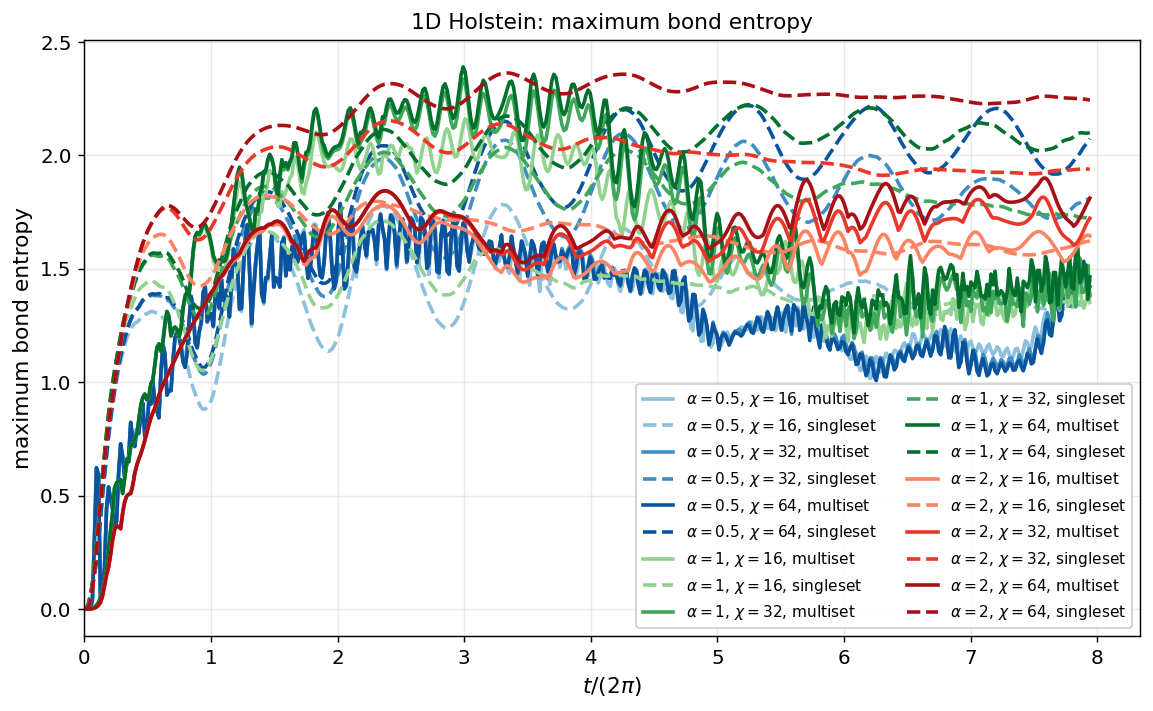

In [4]:
def plot_max_bond_entropy(records):
    bds_by_alpha = {}
    for item in records:
        bds_by_alpha.setdefault(item["alpha"], set()).add(item["bd"])

    fig, ax = plt.subplots(figsize=(9.0, 5.6))
    plotted = 0

    for item in sorted(records, key=lambda x: (x["alpha"], x["bd"], x["method"])):
        try:
            time, _, s_maxbond = load_result(item)
        except FileNotFoundError as exc:
            print(f"[skip] missing file: {exc}")
            continue

        if s_maxbond is None:
            print(f"[skip] no S_maxbond in {item['path'].name}")
            continue

        n = min(len(time), len(s_maxbond))
        linestyle = "-" if item["method"] == "multiset" else "--"
        color = color_for_alpha_bd(item["alpha"], item["bd"], bds_by_alpha)
        label = rf"$\alpha={item['alpha']:g}$, $\chi={item['bd']}$, {item['method']}"
        ax.plot(time[:n] / TIME_SCALE, s_maxbond[:n], lw=2.0, ls=linestyle, color=color, label=label)
        plotted += 1

    ax.set_xlabel(r"$t/(2\pi)$")
    ax.set_ylabel(r"maximum bond entropy")
    ax.set_title("1D Holstein: maximum bond entropy")
    ax.set_xlim(left=0)
    ax.legend(ncol=2, frameon=True, framealpha=0.92)
    fig.tight_layout()

    if SAVE_FIGURES and plotted:
        fig.savefig(FIG_DIR / "max_bond_entropy_vs_time.png", bbox_inches="tight")
        fig.savefig(FIG_DIR / "max_bond_entropy_vs_time.pdf", bbox_inches="tight")

    print(f"plotted {plotted} entropy curves")
    return fig, ax

fig_entropy, ax_entropy = plot_max_bond_entropy(records)
plt.show()

In [12]:
def plot_max_bond_entropy(records, zoom_xlim=(7.5, 8.0)):
    bds_by_alpha = {}
    for item in records:
        bds_by_alpha.setdefault(item["alpha"], set()).add(item["bd"])

    figs_axes = []
    total_plotted = 0

    for alpha in sorted(bds_by_alpha):
        fig, (ax, ax_zoom) = plt.subplots(
            1,
            2,
            figsize=(13.5, 5.4),
            gridspec_kw={"width_ratios": [2.6, 1.15]},
        )

        plotted = 0

        alpha_records = [
            item for item in records
            if item["alpha"] == alpha
        ]

        for item in sorted(alpha_records, key=lambda x: (x["bd"], x["method"])):
            try:
                time, _, s_maxbond = load_result(item)
            except FileNotFoundError as exc:
                print(f"[skip] missing file: {exc}")
                continue

            if s_maxbond is None:
                path = Path(item["path"])
                print(f"[skip] no S_maxbond in {path.name}")
                continue

            time = np.asarray(time, dtype=float) / TIME_SCALE
            s_maxbond = np.asarray(s_maxbond, dtype=float)

            n = min(len(time), len(s_maxbond))
            time = time[:n]
            s_maxbond = s_maxbond[:n]

            linestyle = "-" if item["method"] == "multiset" else "--"
            color = color_for_alpha_bd(item["alpha"], item["bd"], bds_by_alpha)
            label = rf"$\chi={item['bd']}$, {item['method']}"

            ax.plot(
                time,
                s_maxbond,
                lw=2.0,
                ls=linestyle,
                color=color,
                label=label,
            )

            zoom_mask = (time >= zoom_xlim[0]) & (time <= zoom_xlim[1])
            ax_zoom.plot(
                time[zoom_mask],
                s_maxbond[zoom_mask],
                lw=2.0,
                ls=linestyle,
                color=color,
            )

            plotted += 1

        for axis in (ax, ax_zoom):
            axis.grid(True, alpha=0.28)
            axis.set_xlabel(r"$t/(2\pi)$")

        ax.set_ylabel(r"maximum bond entropy")
        ax.set_title(rf"1D Holstein: maximum bond entropy, $\alpha={alpha:g}$")
        ax.set_xlim(left=0)
        ax.legend(ncol=2, frameon=True, framealpha=0.92)

        ax_zoom.set_title(rf"Zoom: {zoom_xlim[0]:g}-{zoom_xlim[1]:g}")
        ax_zoom.set_xlim(*zoom_xlim)
        ax_zoom.set_ylabel(r"maximum bond entropy")

        fig.tight_layout()

        if SAVE_FIGURES and plotted:
            alpha_tag = f"{alpha:g}".replace(".", "p")
            fig.savefig(
                FIG_DIR / f"max_bond_entropy_vs_time_alpha_{alpha_tag}.png",
                bbox_inches="tight",
            )
            fig.savefig(
                FIG_DIR / f"max_bond_entropy_vs_time_alpha_{alpha_tag}.pdf",
                bbox_inches="tight",
            )

        print(f"alpha={alpha:g}: plotted {plotted} entropy curves")

        total_plotted += plotted
        figs_axes.append((fig, ax, ax_zoom))

    print(f"plotted {total_plotted} entropy curves in total")
    return figs_axes

alpha=0.5: plotted 6 entropy curves
alpha=1: plotted 6 entropy curves
alpha=2: plotted 6 entropy curves
plotted 18 entropy curves in total


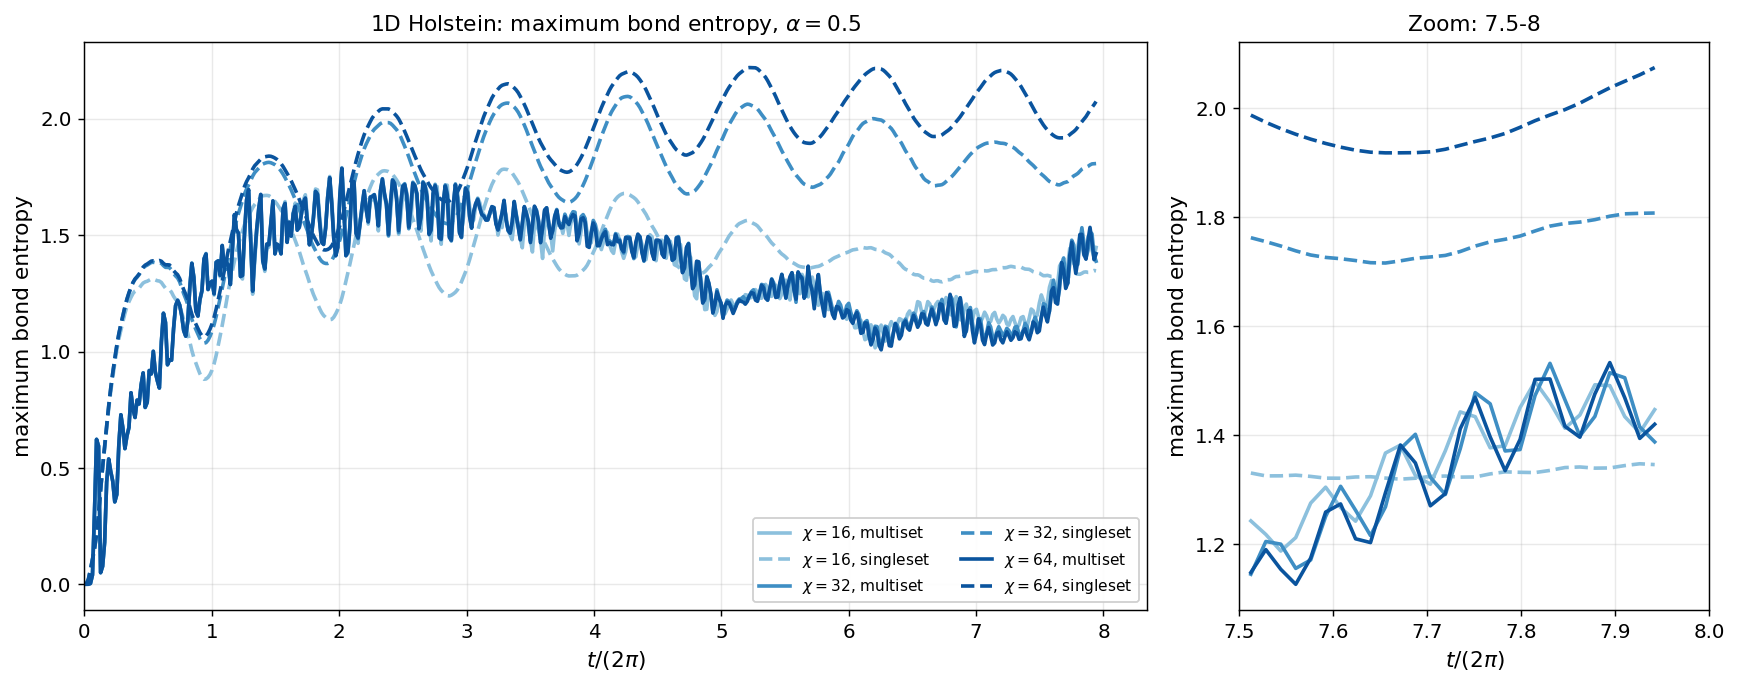

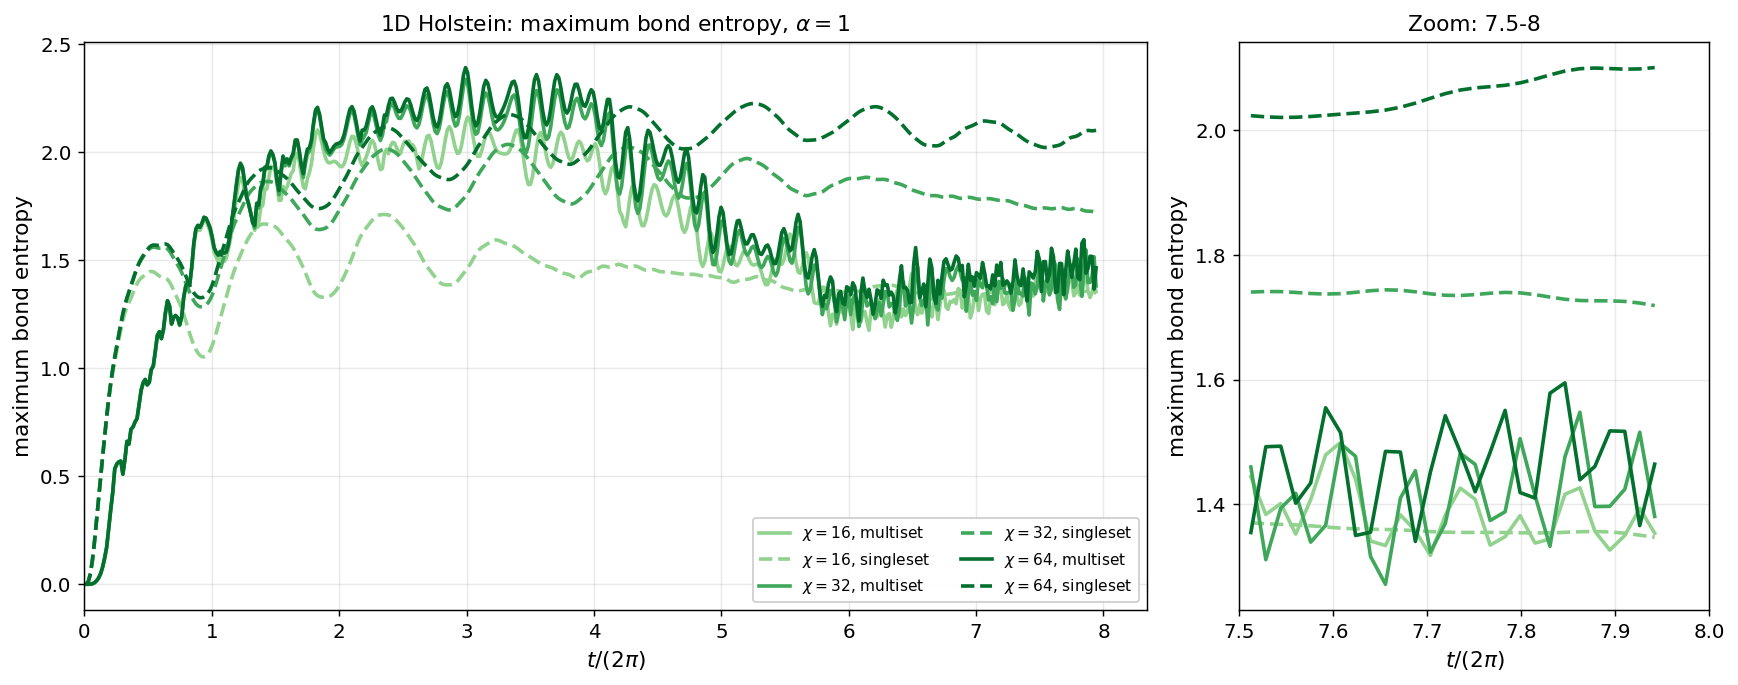

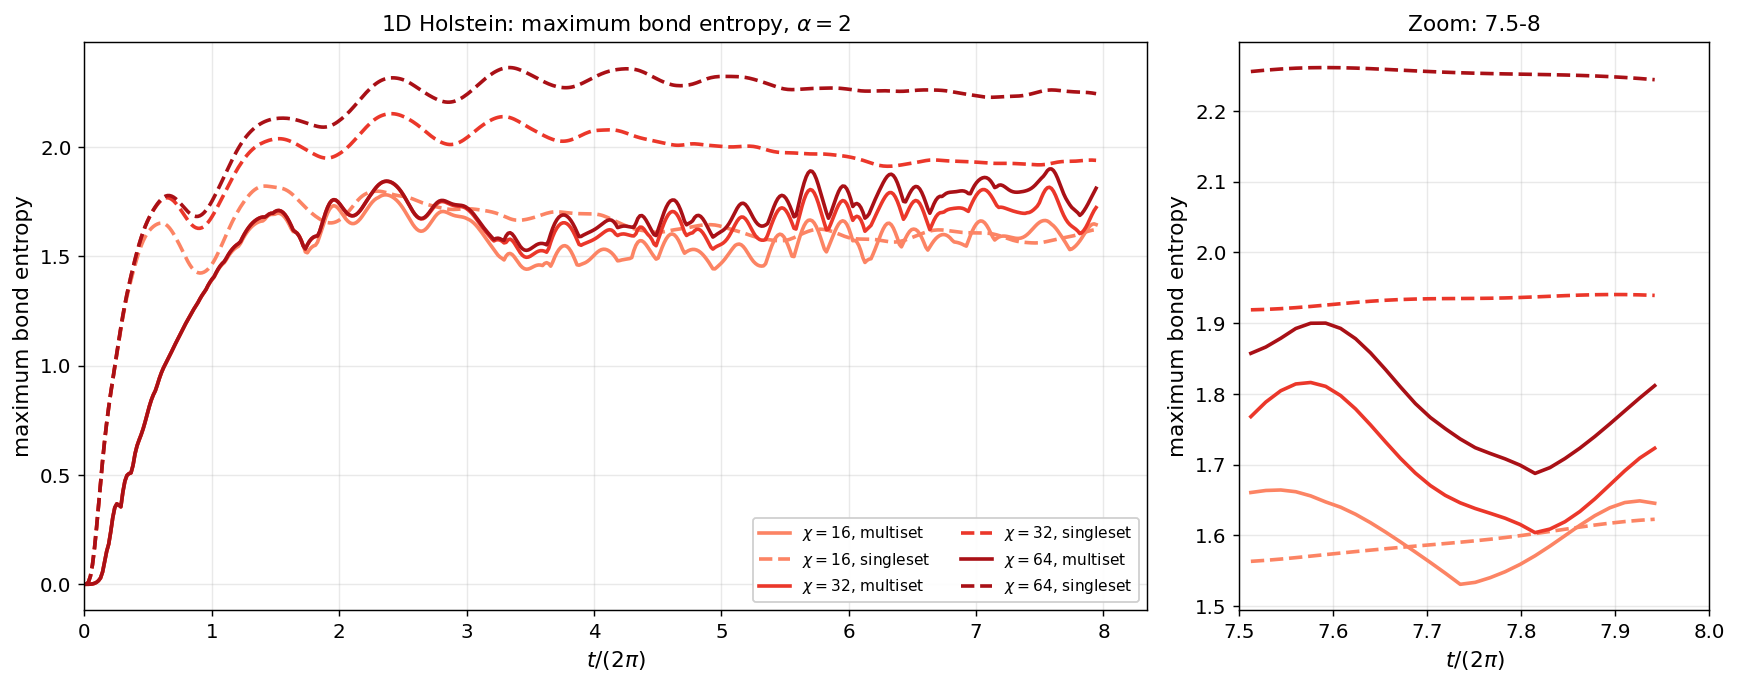

In [13]:
figs_axes_entropy = plot_max_bond_entropy(records)
plt.show()

## RMSD values for all results

This plot shows the raw RMSD time evolution for every discovered alpha, method, and bond dimension. `multiset` is solid and `singleset` is dashed.


plotted 18 RMSD curves


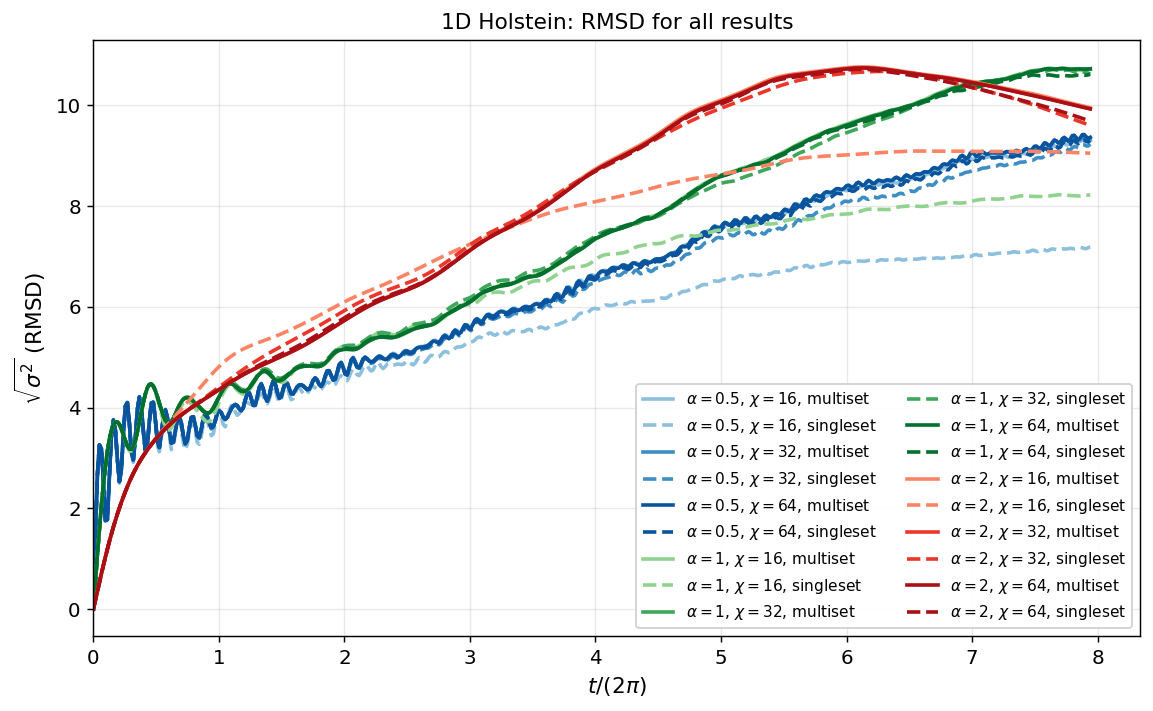

In [5]:
def plot_all_rmsd(records):
    bds_by_alpha = {}
    for item in records:
        bds_by_alpha.setdefault(item["alpha"], set()).add(item["bd"])

    fig, ax = plt.subplots(figsize=(9.0, 5.6))
    plotted = 0

    for item in sorted(records, key=lambda x: (x["alpha"], x["bd"], x["method"])):
        try:
            time, occupations, _ = load_result(item)
        except FileNotFoundError as exc:
            print(f"[skip] missing file: {exc}")
            continue

        alpha = item["alpha"]
        bd = item["bd"]
        method = item["method"]
        time_scaled, rmsd = compute_rmsd(time, occupations)
        linestyle = "-" if method == "multiset" else "--"
        color = color_for_alpha_bd(alpha, bd, bds_by_alpha)
        label = rf"$\alpha={alpha:g}$, $\chi={bd}$, {method}"
        ax.plot(time_scaled, rmsd, lw=2.0, ls=linestyle, color=color, label=label)
        plotted += 1

    ax.set_xlabel(r"$t/(2\pi)$")
    ax.set_ylabel(r"$\sqrt{\sigma^2}$ (RMSD)")
    ax.set_title("1D Holstein: RMSD for all results")
    ax.set_xlim(left=0)
    ax.legend(ncol=2, frameon=True, framealpha=0.92)
    fig.tight_layout()

    if SAVE_FIGURES and plotted:
        fig.savefig(FIG_DIR / "rmsd_vs_time.png", bbox_inches="tight")
        fig.savefig(FIG_DIR / "rmsd_vs_time.pdf", bbox_inches="tight")

    print(f"plotted {plotted} RMSD curves")
    return fig, ax

fig_rmsd, ax_rmsd = plot_all_rmsd(records)
plt.show()


## Figure 2: RMSD convergence error

For each alpha and method, the relative error compares a bond dimension with its doubled reference:

$$\epsilon_\chi(t)=\frac{|RMSD_\chi(t)-RMSD_{2\chi}(t)|}{|RMSD_{2\chi}(t)|}$$

Set `RELATIVE_ERROR_ABS = False` in the first cell if a signed `(RMSD_2chi - RMSD_chi) / RMSD_2chi` curve is needed instead.

plotted 12 RMSD error curves


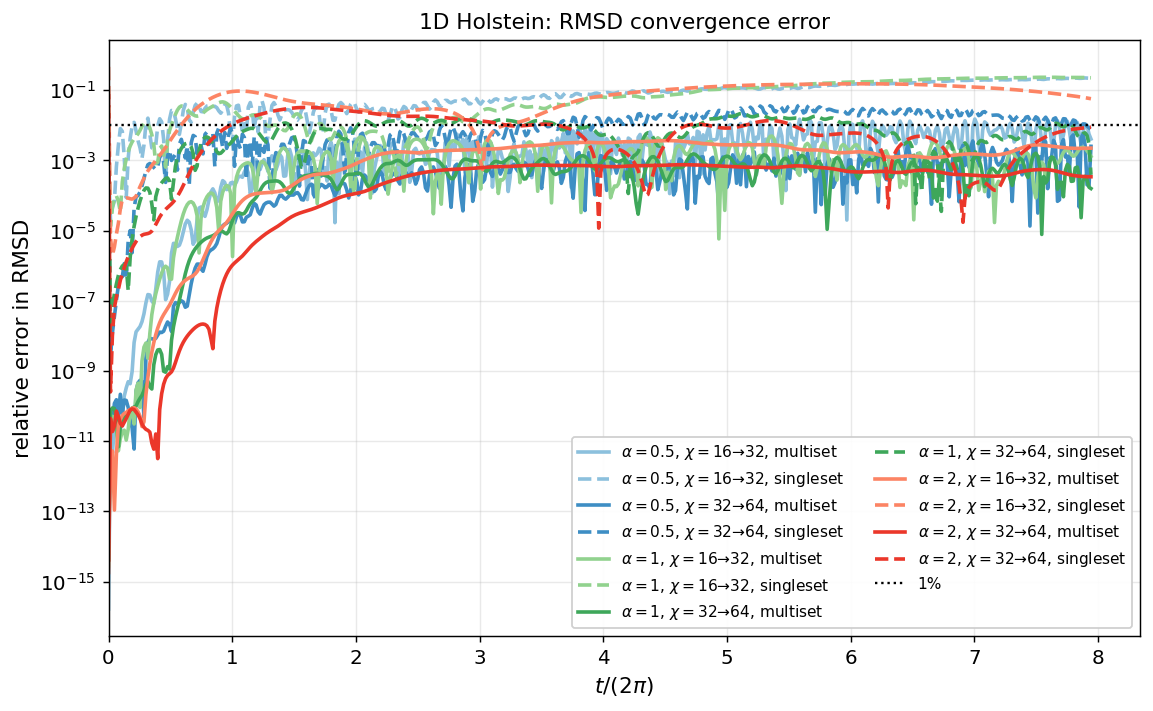

In [6]:
def build_record_index(records):
    return {(item["alpha"], item["method"], item["bd"]): item for item in records}

def relative_rmsd_error(low_item, ref_item):
    time_low, occ_low, _ = load_result(low_item)
    time_ref, occ_ref, _ = load_result(ref_item)

    t_low, rmsd_low = compute_rmsd(time_low, occ_low)
    t_ref, rmsd_ref = compute_rmsd(time_ref, occ_ref)
    n = min(len(t_low), len(t_ref), len(rmsd_low), len(rmsd_ref))

    numerator = rmsd_ref[:n] - rmsd_low[:n]
    denominator = rmsd_ref[:n]
    if RELATIVE_ERROR_ABS:
        numerator = np.abs(numerator)
        denominator = np.abs(denominator)

    with np.errstate(invalid="ignore", divide="ignore"):
        error = np.where(np.abs(denominator) > 1e-12, numerator / denominator, np.nan)

    return t_ref[:n], error

def plot_rmsd_convergence_error(records):
    index = build_record_index(records)
    bds_by_alpha = {}
    for item in records:
        bds_by_alpha.setdefault(item["alpha"], set()).add(item["bd"])

    fig, ax = plt.subplots(figsize=(9.0, 5.6))
    plotted = 0

    for alpha in sorted({item["alpha"] for item in records}):
        for bd in sorted(bds_by_alpha[alpha]):
            for method in ("multiset", "singleset"):
                low_item = index.get((alpha, method, bd))
                ref_item = index.get((alpha, method, 2 * bd))
                if low_item is None or ref_item is None:
                    continue

                try:
                    time, error = relative_rmsd_error(low_item, ref_item)
                except FileNotFoundError as exc:
                    print(f"[skip] missing file: {exc}")
                    continue

                linestyle = "-" if method == "multiset" else "--"
                color = color_for_alpha_bd(alpha, bd, bds_by_alpha)
                label = rf"$\alpha={alpha:g}$, $\chi={bd}\to{2 * bd}$, {method}"
                ax.plot(time, error, lw=2.0, ls=linestyle, color=color, label=label)
                plotted += 1

    ax.axhline(0.01, color="black", ls=":", lw=1.3, label="1%")
    ax.set_yscale("log")
    ax.set_xlabel(r"$t/(2\pi)$")
    ax.set_ylabel(r"relative error in RMSD")
    ax.set_title("1D Holstein: RMSD convergence error")
    ax.set_xlim(left=0)
    ax.legend(ncol=2, frameon=True, framealpha=0.92)
    fig.tight_layout()

    if SAVE_FIGURES and plotted:
        fig.savefig(FIG_DIR / "rmsd_convergence_error.png", bbox_inches="tight")
        fig.savefig(FIG_DIR / "rmsd_convergence_error.pdf", bbox_inches="tight")

    print(f"plotted {plotted} RMSD error curves")
    return fig, ax

fig_error, ax_error = plot_rmsd_convergence_error(records)
plt.show()

In [10]:
def build_record_index(records):
    return {(item["alpha"], item["method"], item["bd"]): item for item in records}


def relative_rmsd_error(low_item, ref_item):
    time_low, occ_low, _ = load_result(low_item)
    time_ref, occ_ref, _ = load_result(ref_item)

    t_low, rmsd_low = compute_rmsd(time_low, occ_low)
    t_ref, rmsd_ref = compute_rmsd(time_ref, occ_ref)
    n = min(len(t_low), len(t_ref), len(rmsd_low), len(rmsd_ref))

    numerator = rmsd_ref[:n] - rmsd_low[:n]
    denominator = rmsd_ref[:n]
    if RELATIVE_ERROR_ABS:
        numerator = np.abs(numerator)
        denominator = np.abs(denominator)

    with np.errstate(invalid="ignore", divide="ignore"):
        error = np.where(np.abs(denominator) > 1e-12, numerator / denominator, np.nan)

    return t_ref[:n], error


def plot_rmsd_convergence_error(records, zoom_xlim=(7.5, 8.0)):
    index = build_record_index(records)

    bds_by_alpha = {}
    for item in records:
        bds_by_alpha.setdefault(item["alpha"], set()).add(item["bd"])

    figs_axes = []
    total_plotted = 0

    for alpha in sorted(bds_by_alpha):
        fig, (ax, ax_zoom) = plt.subplots(
            1,
            2,
            figsize=(13.5, 5.4),
            gridspec_kw={"width_ratios": [2.6, 1.15]},
        )

        plotted = 0

        for bd in sorted(bds_by_alpha[alpha]):
            for method in ("multiset", "singleset"):
                low_item = index.get((alpha, method, bd))
                ref_item = index.get((alpha, method, 2 * bd))
                if low_item is None or ref_item is None:
                    continue

                try:
                    time, error = relative_rmsd_error(low_item, ref_item)
                except FileNotFoundError as exc:
                    print(f"[skip] missing file: {exc}")
                    continue

                linestyle = "-" if method == "multiset" else "--"
                color = color_for_alpha_bd(alpha, bd, bds_by_alpha)
                label = rf"$\chi={bd}\to{2 * bd}$, {method}"

                ax.plot(
                    time,
                    error,
                    lw=2.0,
                    ls=linestyle,
                    color=color,
                    label=label,
                )

                zoom_mask = (time >= zoom_xlim[0]) & (time <= zoom_xlim[1])
                ax_zoom.plot(
                    time[zoom_mask],
                    error[zoom_mask],
                    lw=2.0,
                    ls=linestyle,
                    color=color,
                )

                plotted += 1

        for axis in (ax, ax_zoom):
            axis.axhline(0.01, color="black", ls=":", lw=1.3)
            axis.set_yscale("log")
            axis.grid(True, alpha=0.28)
            axis.set_xlabel(r"$t/(2\pi)$")

        ax.set_ylabel(r"relative error in RMSD")
        ax.set_title(rf"1D Holstein: RMSD convergence error, $\alpha={alpha:g}$")
        ax.set_xlim(left=0)
        ax.legend(ncol=2, frameon=True, framealpha=0.92)

        ax_zoom.set_title(rf"Zoom: {zoom_xlim[0]:g}-{zoom_xlim[1]:g}")
        ax_zoom.set_xlim(*zoom_xlim)

        fig.tight_layout()

        if SAVE_FIGURES and plotted:
            alpha_tag = f"{alpha:g}".replace(".", "p")
            fig.savefig(FIG_DIR / f"rmsd_convergence_error_alpha_{alpha_tag}.png", bbox_inches="tight")
            fig.savefig(FIG_DIR / f"rmsd_convergence_error_alpha_{alpha_tag}.pdf", bbox_inches="tight")

        print(f"alpha={alpha:g}: plotted {plotted} RMSD error curves")

        total_plotted += plotted
        figs_axes.append((fig, ax, ax_zoom))

    print(f"plotted {total_plotted} RMSD error curves in total")
    return figs_axes

alpha=0.5: plotted 4 RMSD error curves
alpha=1: plotted 4 RMSD error curves
alpha=2: plotted 4 RMSD error curves
plotted 12 RMSD error curves in total


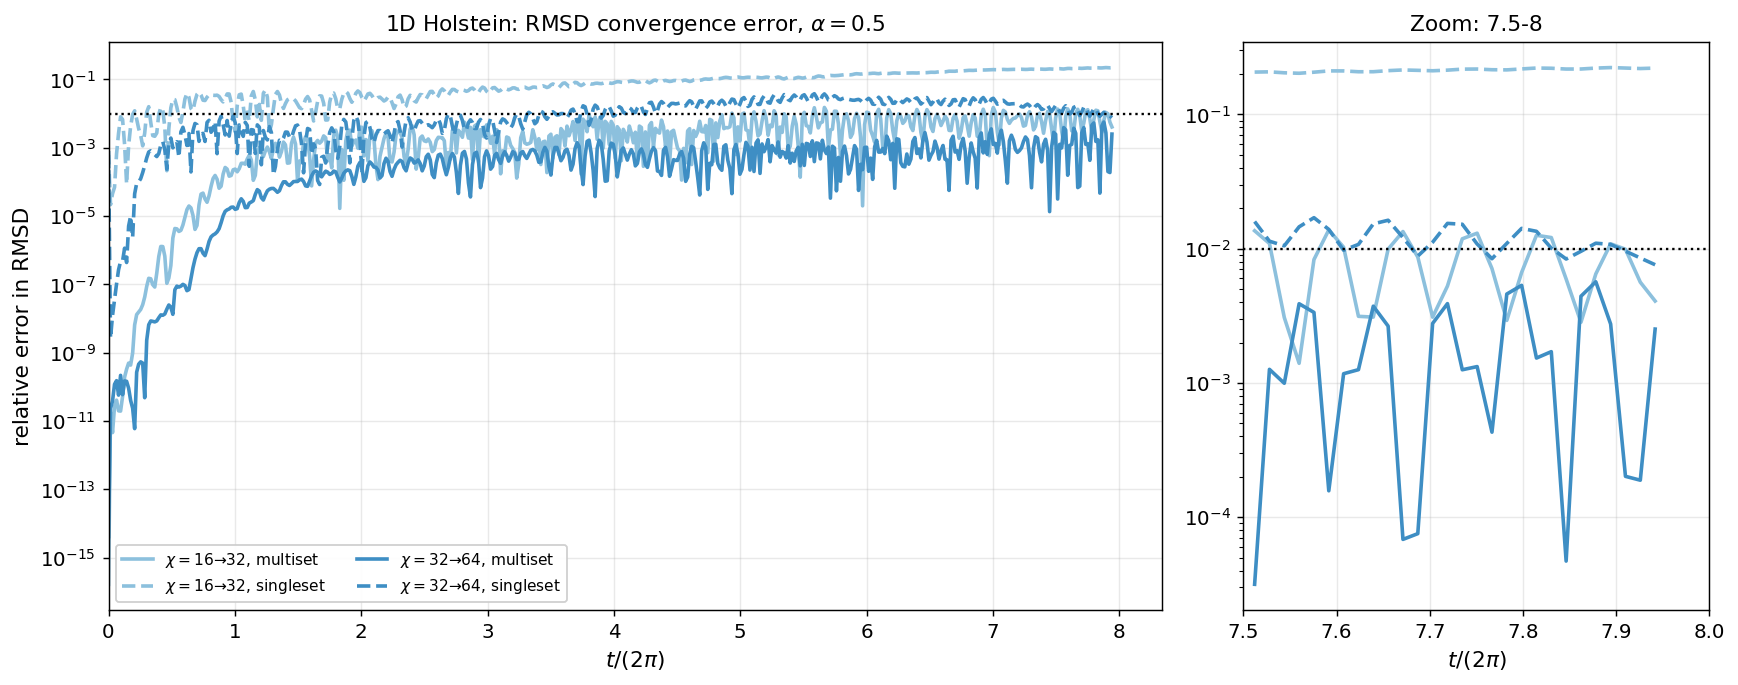

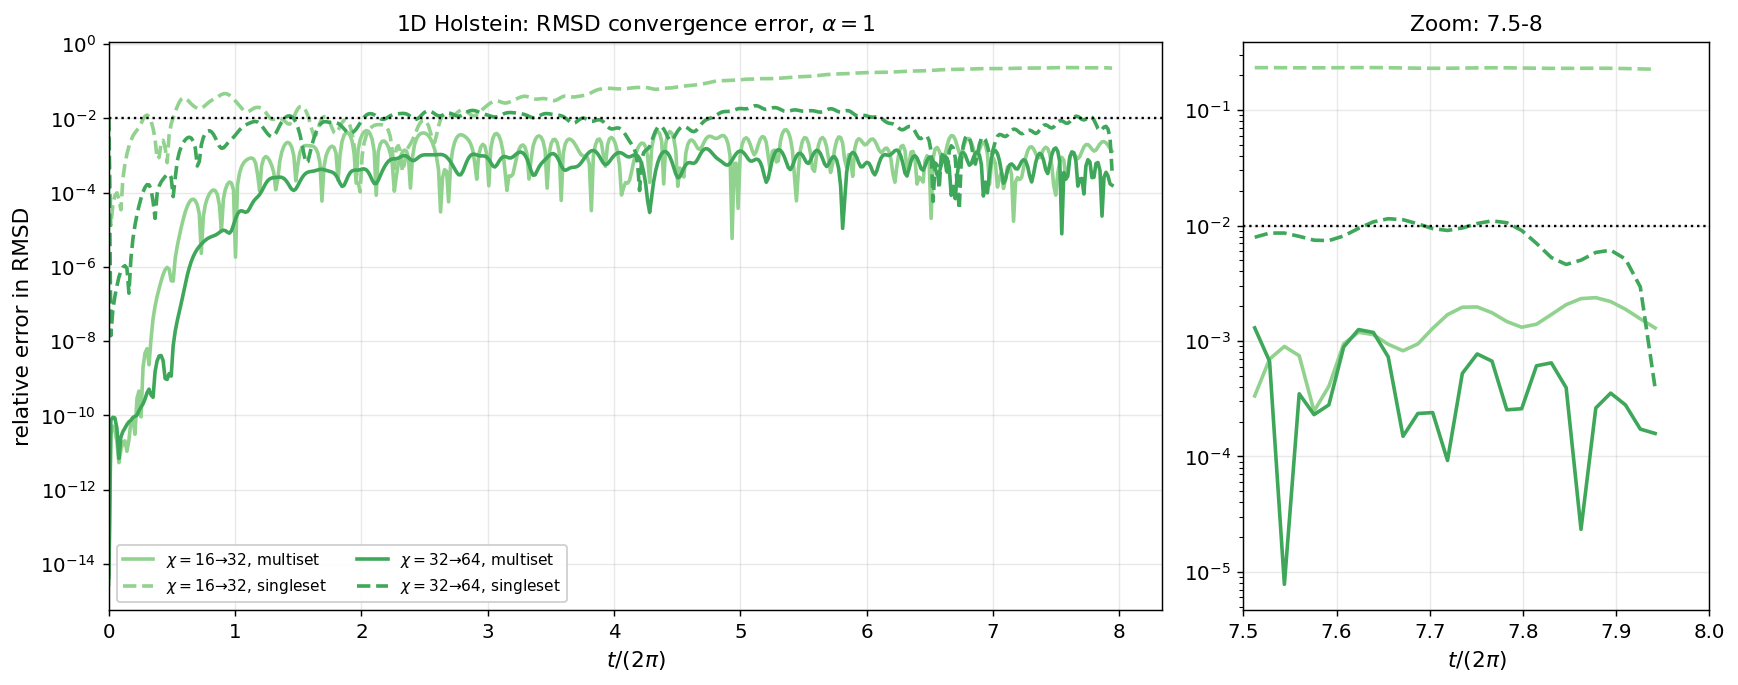

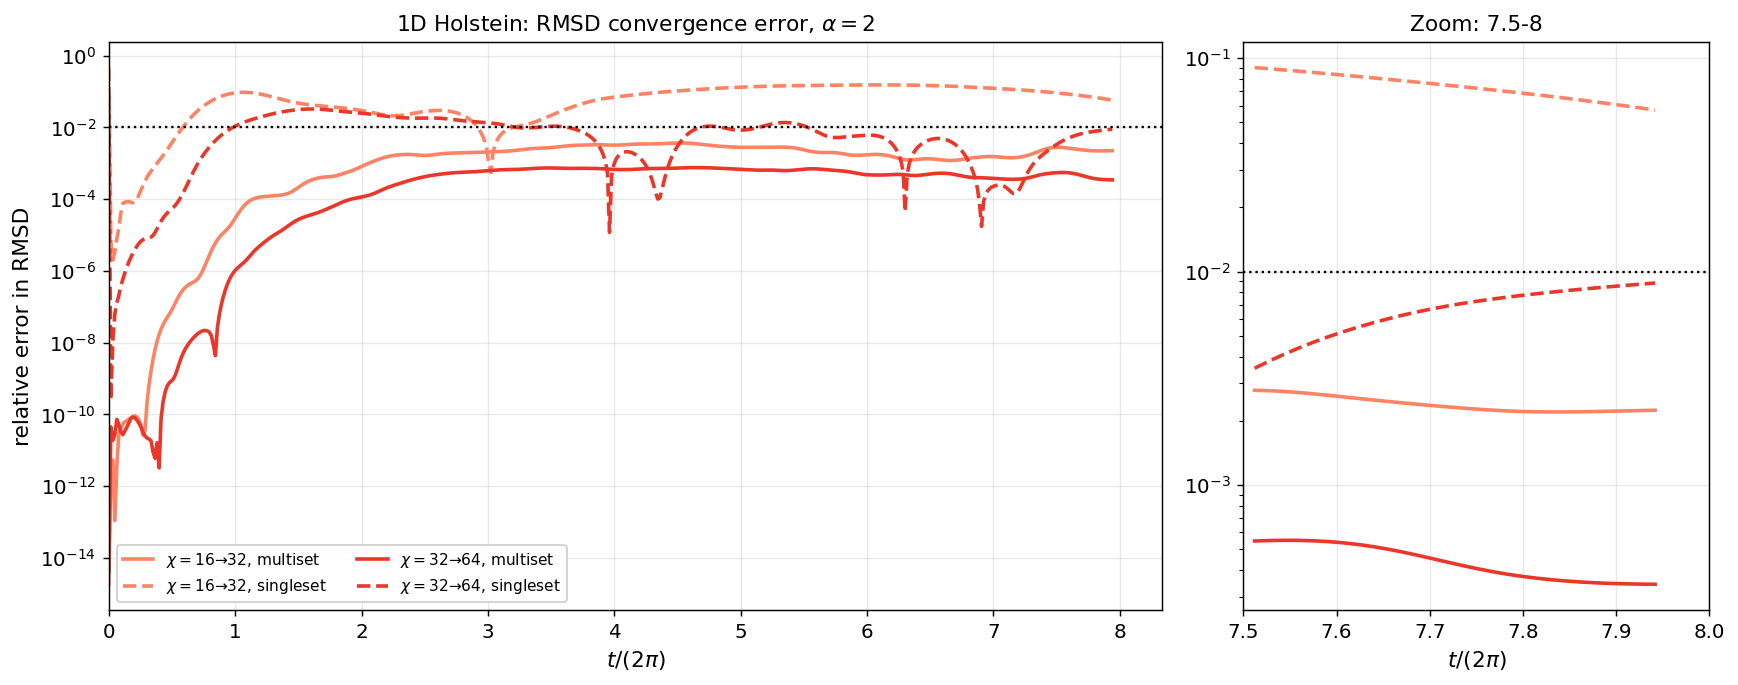

In [11]:
figs_axes_error = plot_rmsd_convergence_error(records)
plt.show()

## Figure 3: electron-phonon entanglement entropy

This plot reads `S_el` from each `.npz` file and shows the electron-phonon entanglement entropy time evolution for both `singleset` and `multiset`. Files without `S_el` are skipped.


plotted 18 S_el curves


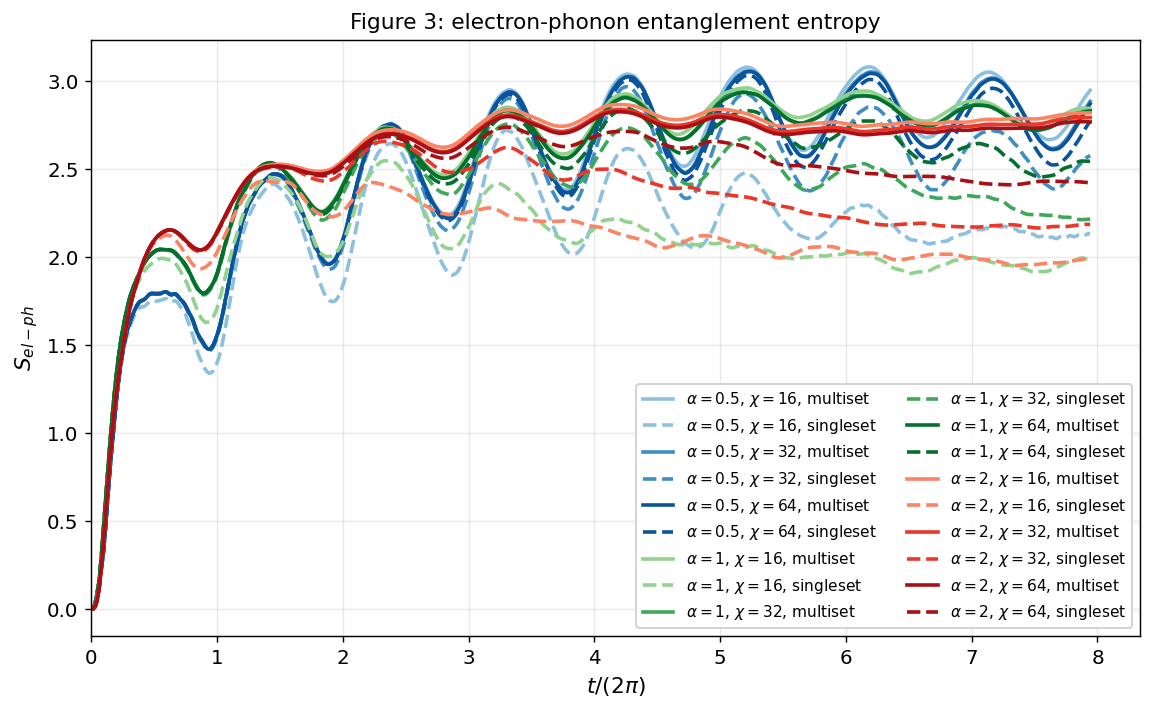

In [ ]:
def build_record_index(records):
    return {(item["alpha"], item["method"], item["bd"]): item for item in records}


def relative_rmsd_error(low_item, ref_item):
    time_low, occ_low, _ = load_result(low_item)
    time_ref, occ_ref, _ = load_result(ref_item)

    t_low, rmsd_low = compute_rmsd(time_low, occ_low)
    t_ref, rmsd_ref = compute_rmsd(time_ref, occ_ref)
    n = min(len(t_low), len(t_ref), len(rmsd_low), len(rmsd_ref))

    numerator = rmsd_ref[:n] - rmsd_low[:n]
    denominator = rmsd_ref[:n]
    if RELATIVE_ERROR_ABS:
        numerator = np.abs(numerator)
        denominator = np.abs(denominator)

    with np.errstate(invalid="ignore", divide="ignore"):
        error = np.where(np.abs(denominator) > 1e-12, numerator / denominator, np.nan)

    return t_ref[:n], error


def plot_rmsd_convergence_error(records, zoom_xlim=(7.5, 8.0)):
    index = build_record_index(records)

    bds_by_alpha = {}
    for item in records:
        bds_by_alpha.setdefault(item["alpha"], set()).add(item["bd"])

    figs_axes = []
    total_plotted = 0

    for alpha in sorted(bds_by_alpha):
        fig, (ax, ax_zoom) = plt.subplots(
            1,
            2,
            figsize=(13.5, 5.4),
            gridspec_kw={"width_ratios": [2.6, 1.15]},
        )

        plotted = 0

        for bd in sorted(bds_by_alpha[alpha]):
            for method in ("multiset", "singleset"):
                low_item = index.get((alpha, method, bd))
                ref_item = index.get((alpha, method, 2 * bd))
                if low_item is None or ref_item is None:
                    continue

                try:
                    time, error = relative_rmsd_error(low_item, ref_item)
                except FileNotFoundError as exc:
                    print(f"[skip] missing file: {exc}")
                    continue

                linestyle = "-" if method == "multiset" else "--"
                color = color_for_alpha_bd(alpha, bd, bds_by_alpha)
                label = rf"$\chi={bd}\to{2 * bd}$, {method}"

                ax.plot(
                    time,
                    error,
                    lw=2.0,
                    ls=linestyle,
                    color=color,
                    label=label,
                )

                zoom_mask = (time >= zoom_xlim[0]) & (time <= zoom_xlim[1])
                ax_zoom.plot(
                    time[zoom_mask],
                    error[zoom_mask],
                    lw=2.0,
                    ls=linestyle,
                    color=color,
                )

                plotted += 1

        for axis in (ax, ax_zoom):
            axis.axhline(0.01, color="black", ls=":", lw=1.3)
            axis.set_yscale("log")
            axis.grid(True, alpha=0.28)
            axis.set_xlabel(r"$t/(2\pi)$")

        ax.set_ylabel(r"relative error in RMSD")
        ax.set_title(rf"1D Holstein: RMSD convergence error, $\alpha={alpha:g}$")
        ax.set_xlim(left=0)
        ax.legend(ncol=2, frameon=True, framealpha=0.92)

        ax_zoom.set_title(rf"Zoom: {zoom_xlim[0]:g}-{zoom_xlim[1]:g}")
        ax_zoom.set_xlim(*zoom_xlim)

        fig.tight_layout()

        if SAVE_FIGURES and plotted:
            alpha_tag = f"{alpha:g}".replace(".", "p")
            fig.savefig(FIG_DIR / f"rmsd_convergence_error_alpha_{alpha_tag}.png", bbox_inches="tight")
            fig.savefig(FIG_DIR / f"rmsd_convergence_error_alpha_{alpha_tag}.pdf", bbox_inches="tight")

        print(f"alpha={alpha:g}: plotted {plotted} RMSD error curves")

        total_plotted += plotted
        figs_axes.append((fig, ax, ax_zoom))

    print(f"plotted {total_plotted} RMSD error curves in total")
    return figs_axes

In [ ]:
def plot_el_ph_entropy(records):
    bds_by_alpha = {}
    for item in records:
        bds_by_alpha.setdefault(item["alpha"], set()).add(item["bd"])

    alphas = sorted(bds_by_alpha.keys())

    fig, axes = plt.subplots(
        1,
        len(alphas),
        figsize=(5.0 * len(alphas), 5.2),
        sharey=True
    )

    if len(alphas) == 1:
        axes = [axes]

    plotted = 0

    for ax, alpha in zip(axes, alphas):
        alpha_records = [
            item for item in records
            if item["alpha"] == alpha
        ]

        for item in sorted(alpha_records, key=lambda x: (x["bd"], x["method"])):
            path = Path(item["path"])
            if not path.exists():
                print(f"[skip] missing file: {path}")
                continue
            if path.suffix != ".npz":
                print(f"[skip] S_el is only available from npz: {path.name}")
                continue

            data = np.load(path, allow_pickle=True)
            if "S_el" not in data.files:
                print(f"[skip] no S_el in {path.name}")
                continue

            time = np.asarray(data["time_series"], dtype=float)
            s_el = np.real_if_close(np.asarray(data["S_el"]))
            s_el = np.asarray(s_el, dtype=float)
            n = min(len(time), len(s_el))

            bd = item["bd"]
            method = item["method"]
            linestyle = "-" if method == "multiset" else "--"
            color = color_for_alpha_bd(alpha, bd, bds_by_alpha)
            label = rf"$\chi={bd}$, {method}"

            ax.plot(
                time[:n] / TIME_SCALE,
                s_el[:n],
                lw=2.0,
                ls=linestyle,
                color=color,
                label=label
            )

            plotted += 1

        ax.set_title(rf"$\alpha={alpha:g}$")
        ax.set_xlabel(r"$t/(2\pi)$")
        ax.set_xlim(left=0)
        ax.legend(frameon=True, framealpha=0.92)

    axes[0].set_ylabel(r"$S_{el-ph}$")
    fig.suptitle("Figure 3: electron-phonon entanglement entropy")
    fig.tight_layout()

    if SAVE_FIGURES and plotted:
        fig.savefig(FIG_DIR / "figure3_sel_ph_vs_time.png", bbox_inches="tight")
        fig.savefig(FIG_DIR / "figure3_sel_ph_vs_time.pdf", bbox_inches="tight")

    print(f"plotted {plotted} S_el curves")
    return fig, axes

plotted 18 S_el curves


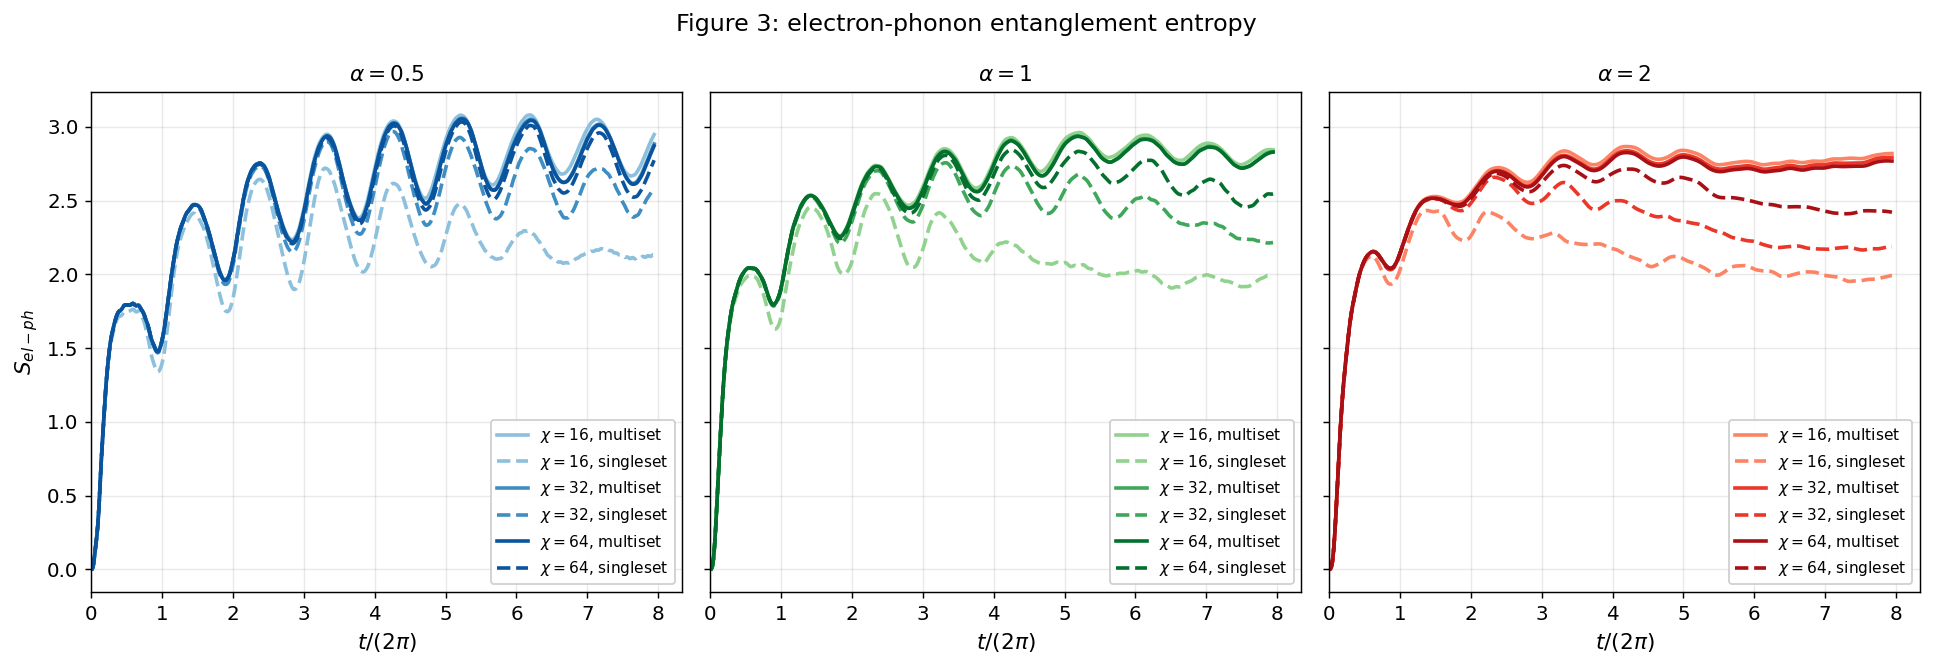

In [9]:
fig3, axes3 = plot_el_ph_entropy(records)
plt.show()

## Figure 4: maximum bond entropy vs electron-phonon entanglement entropy

This parametric plot uses `S_el` from Figure 3 as the x-axis and `S_maxbond` from Figure 1 as the y-axis. Each alpha is shown in a separate panel.


plotted 18 S_maxbond vs S_el curves


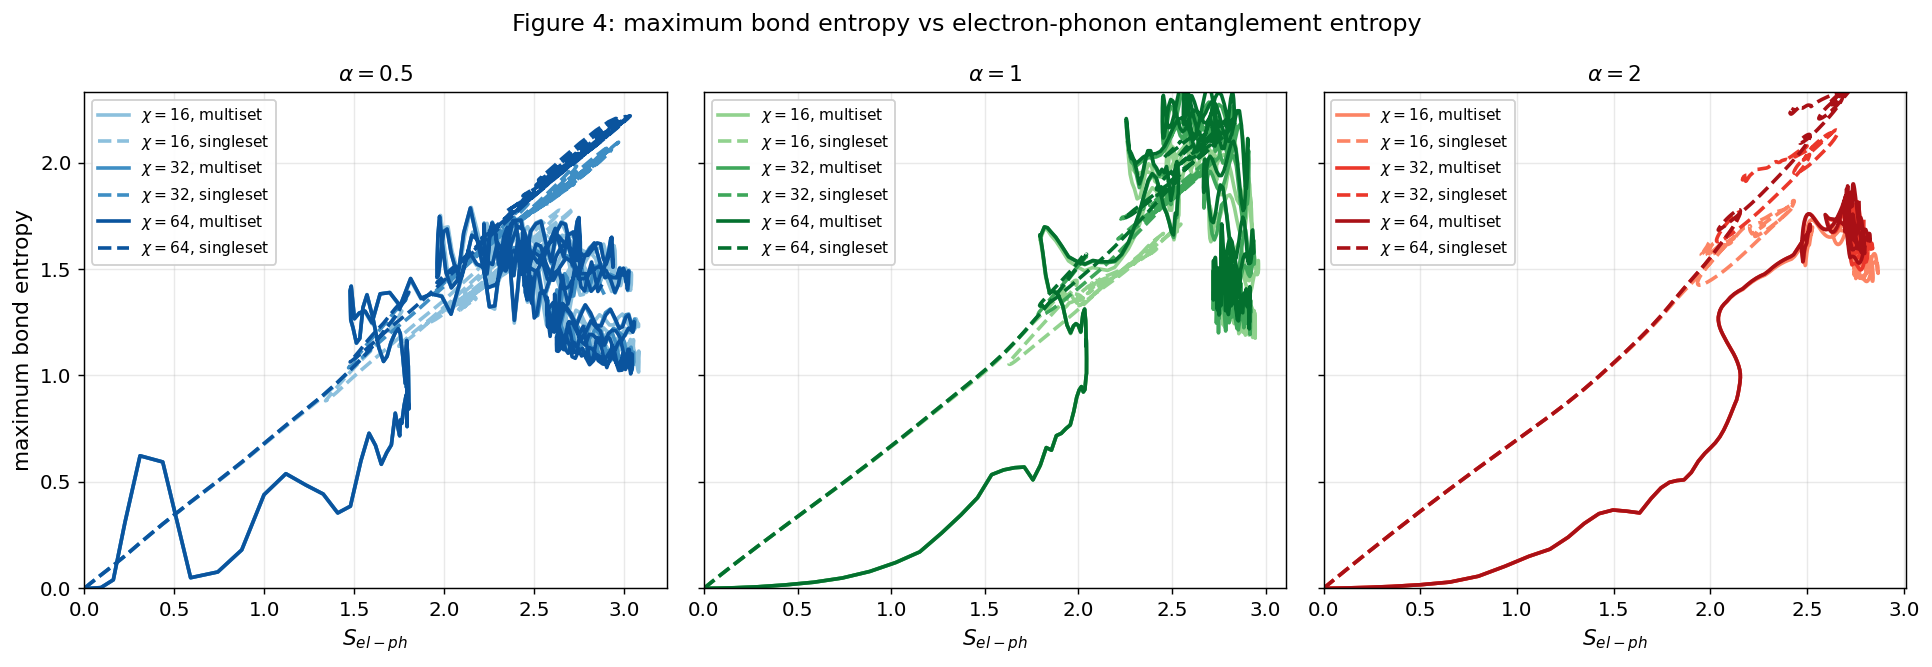

In [14]:
def plot_bond_entropy_vs_el_ph_entropy(records):
    bds_by_alpha = {}
    for item in records:
        bds_by_alpha.setdefault(item["alpha"], set()).add(item["bd"])

    alphas = sorted(bds_by_alpha.keys())

    fig, axes = plt.subplots(
        1,
        len(alphas),
        figsize=(5.0 * len(alphas), 5.2),
        sharex=False,
        sharey=True,
    )

    if len(alphas) == 1:
        axes = [axes]

    plotted = 0

    for ax, alpha in zip(axes, alphas):
        alpha_records = [
            item for item in records
            if item["alpha"] == alpha
        ]

        for item in sorted(alpha_records, key=lambda x: (x["bd"], x["method"])):
            path = Path(item["path"])
            if not path.exists():
                print(f"[skip] missing file: {path}")
                continue
            if path.suffix != ".npz":
                print(f"[skip] S_el/S_maxbond are only available from npz: {path.name}")
                continue

            data = np.load(path, allow_pickle=True)
            missing = [key for key in ("S_el", "S_maxbond") if key not in data.files]
            if missing:
                print(f"[skip] missing {missing} in {path.name}")
                continue

            s_el = np.real_if_close(np.asarray(data["S_el"]))
            s_el = np.asarray(s_el, dtype=float)
            s_maxbond = np.real_if_close(np.asarray(data["S_maxbond"]))
            s_maxbond = np.asarray(s_maxbond, dtype=float)
            n = min(len(s_el), len(s_maxbond))

            bd = item["bd"]
            method = item["method"]
            linestyle = "-" if method == "multiset" else "--"
            color = color_for_alpha_bd(alpha, bd, bds_by_alpha)
            label = rf"$\chi={bd}$, {method}"

            ax.plot(
                s_el[:n],
                s_maxbond[:n],
                lw=2.0,
                ls=linestyle,
                color=color,
                label=label,
            )

            plotted += 1

        ax.set_title(rf"$\alpha={alpha:g}$")
        ax.set_xlabel(r"$S_{el-ph}$")
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)
        ax.legend(frameon=True, framealpha=0.92)

    axes[0].set_ylabel(r"maximum bond entropy")
    fig.suptitle("Figure 4: maximum bond entropy vs electron-phonon entanglement entropy")
    fig.tight_layout()

    if SAVE_FIGURES and plotted:
        fig.savefig(FIG_DIR / "figure4_smaxbond_vs_sel_ph.png", bbox_inches="tight")
        fig.savefig(FIG_DIR / "figure4_smaxbond_vs_sel_ph.pdf", bbox_inches="tight")

    print(f"plotted {plotted} S_maxbond vs S_el curves")
    return fig, axes


fig4, axes4 = plot_bond_entropy_vs_el_ph_entropy(records)
plt.show()